# 01 · Retrieval baseline and BM25 tuning

> **Goal.** Establish the lexical (BM25) retrieval baseline on the package code,
> understand *why* it ranks the way it does, and tune its parameters against a
> golden set instead of accepting defaults on faith.

Retrieval is the foundation of a RAG system: a generator can only be as faithful
as the evidence it is handed. This notebook treats retrieval as a measurable
component — we index the corpus, dissect a single query, then run a parameter
sweep over BM25's `k1` and `b` to choose a configuration with evidence.

**Contents**
1. Corpus and chunking overview
2. Anatomy of a single BM25 query
3. `k1` × `b` parameter sweep on recall and MRR
4. Takeaways

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ragops_lab.ingestion import ChunkingConfig, ingest_directory, load_chunks_jsonl
from ragops_lab.retrieval import (
    BM25Retriever,
    FakeEmbeddingClient,
    HybridRetriever,
    RetrievalGoldenExample,
    VectorRetriever,
    evaluate_retrieval,
    tokenize,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 88)

DATA = Path("../data")
ARTIFACTS = Path("../artifacts")
CHUNKING = ChunkingConfig(chunk_size=400, overlap=60)


def build_corpus() -> list:
    """Ingest the sample corpus into chunks (the shared starting point)."""
    return ingest_directory(DATA / "sample_documents", DATA / "processed" / "chunks.jsonl", CHUNKING)


def shared_vocabulary(chunks: list) -> list[str]:
    """Fixed vocabulary so query and chunk embeddings share a vector space."""
    return sorted({term for chunk in chunks for term in tokenize(chunk.text)})


def load_golden() -> list[RetrievalGoldenExample]:
    """Load the golden retrieval set."""
    rows = json.loads((DATA / "golden" / "qa.json").read_text())
    return [RetrievalGoldenExample(**row) for row in rows]

In [2]:
chunks = build_corpus()
golden = load_golden()
print(f"{len(chunks)} chunks from {len({c.document_id for c in chunks})} documents")
print(f"{len(golden)} golden questions")

37 chunks from 11 documents
16 golden questions


## 1. Corpus and chunking overview

The corpus is a small knowledge base about retrieval and LLMOps, plus a couple
of off-topic *distractor* documents (Apollo, photosynthesis) whose only job is to
make precision matter — a retriever that pulls them for an on-topic query is
penalised. Chunking is **character-based** (`chunk_size=400`, `overlap=60`), so
longer documents split into several chunks and ranking *within* a document is a
real problem.

In [3]:
overview = (
    pd.DataFrame(
        {
            "document": [c.document_id for c in chunks],
            "chars": [len(c.text) for c in chunks],
            "tokens": [len(tokenize(c.text)) for c in chunks],
        }
    )
    .groupby("document")
    .agg(chunks=("chars", "size"), total_chars=("chars", "sum"), total_tokens=("tokens", "sum"))
    .sort_values("chunks", ascending=False)
)
overview

,chunks,total_chars,total_tokens
document,,,
chunking-strategies,4,1265,202
faithfulness-grounding,4,1303,211
llmops-observability,4,1313,200
prompt-design,4,1312,217
rag-evaluation,4,1350,209
reranking,4,1271,202
hybrid-retrieval,3,1116,182
lexical-retrieval,3,1141,192
photosynthesis,3,960,145


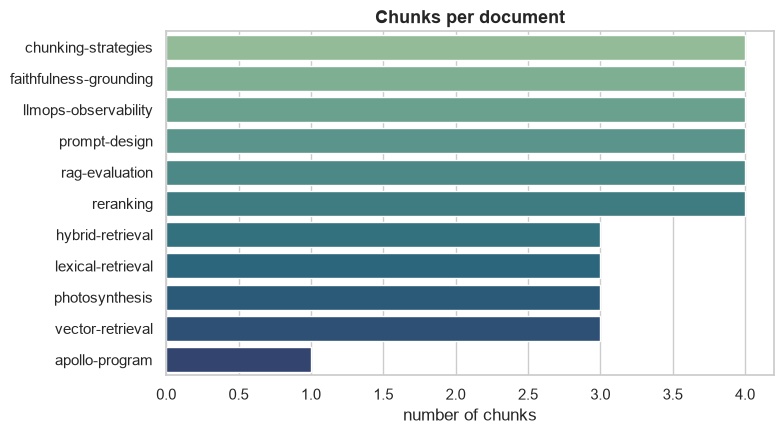

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=overview["chunks"], y=overview.index, hue=overview.index, palette="crest", legend=False, ax=ax)
ax.set_title("Chunks per document", fontsize=13, weight="bold")
ax.set_xlabel("number of chunks")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 2. Anatomy of a single BM25 query

A score with no explanation is not debuggable. The retriever returns the
`matched_terms` per result, so we can see exactly which query terms drove each
chunk's rank — the difference between a trustworthy retrieval layer and a black
box.

In [5]:
retriever = BM25Retriever(chunks)
query = "How is the BM25 k1 parameter related to term frequency?"
results = retriever.search(query, top_k=5)

anatomy = pd.DataFrame(
    {
        "rank": [r.rank for r in results],
        "chunk_id": [r.chunk.chunk_id for r in results],
        "score": [round(r.score, 3) for r in results],
        "matched_terms": [", ".join(r.matched_terms) for r in results],
        "preview": [r.chunk.text[:62].replace(chr(10), " ") for r in results],
    }
)
anatomy

,rank,chunk_id,score,matched_terms,preview
0,1,lexical-retrieval:1,19.309,"bm25, frequency, how, is, k1, parameter, term, the, to",fairly rewarded for containing more words. BM25 exposes two t
1,2,lexical-retrieval:0,10.630,"bm25, frequency, is, term, the",# Lexical Retrieval and BM25 Lexical retrieval ranks document
2,3,lexical-retrieval:2,5.991,"bm25, is, k1, the, to",default is k1 of 1.5 and b of 0.75. The strength of lexical r
3,4,rag-evaluation:1,4.532,"how, the, to",metric to watch when a downstream generator can tolerate some
4,5,vector-retrieval:0,3.455,"is, related, the, to",# Vector Retrieval and Embeddings Vector retrieval represents


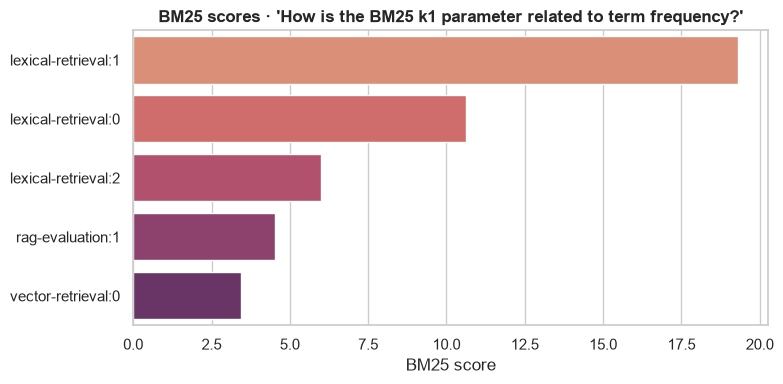

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=[r.score for r in results],
    y=[r.chunk.chunk_id for r in results],
    hue=[r.chunk.chunk_id for r in results],
    palette="flare",
    legend=False,
    ax=ax,
)
ax.set_title(f"BM25 scores · {query!r}", fontsize=12, weight="bold")
ax.set_xlabel("BM25 score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Parameter sweep: `k1` × `b`

BM25's defaults (`k1=1.5`, `b=0.75`) are conventions, not laws. `k1` sets how
fast term-frequency saturates; `b` sets how hard long passages are penalised.
We sweep both over the golden set and read the best cell off a heatmap — the
same procedure scales to a real corpus, only the numbers change.

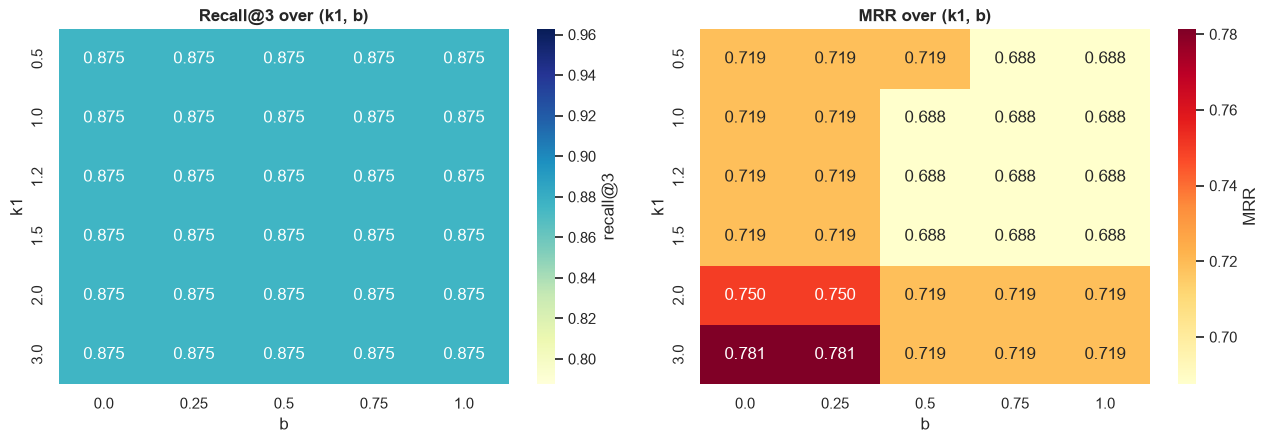

In [7]:
k1_values = [0.5, 1.0, 1.2, 1.5, 2.0, 3.0]
b_values = [0.0, 0.25, 0.5, 0.75, 1.0]

records = []
for k1 in k1_values:
    for b in b_values:
        tuned = BM25Retriever(chunks, k1=k1, b=b)
        report = evaluate_retrieval(tuned, golden, top_k=3)
        records.append({"k1": k1, "b": b, "recall@3": report.recall_at_k, "mrr": report.mean_reciprocal_rank})

sweep = pd.DataFrame(records)
recall_grid = sweep.pivot(index="k1", columns="b", values="recall@3")
mrr_grid = sweep.pivot(index="k1", columns="b", values="mrr")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.heatmap(recall_grid, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "recall@3"})
axes[0].set_title("Recall@3 over (k1, b)", weight="bold")
sns.heatmap(mrr_grid, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "MRR"})
axes[1].set_title("MRR over (k1, b)", weight="bold")
plt.tight_layout()
plt.show()

In [8]:
best = sweep.sort_values(["recall@3", "mrr"], ascending=False).head(5).reset_index(drop=True)
default_row = sweep[(sweep.k1 == 1.5) & (sweep.b == 0.75)].iloc[0]
print(f"default (k1=1.5, b=0.75): recall@3={default_row['recall@3']:.3f}  mrr={default_row['mrr']:.3f}")
print("top configurations:")
best

default (k1=1.5, b=0.75): recall@3=0.875  mrr=0.688
top configurations:


,k1,b,recall@3,mrr
0,3.0,0.00,0.875,0.78125
1,3.0,0.25,0.875,0.78125
2,2.0,0.00,0.875,0.75000
3,2.0,0.25,0.875,0.75000
4,0.5,0.00,0.875,0.71875


## 4. Takeaways

- BM25 ranking is **explainable** — every result carries the query terms that
  earned its score, which is what makes a retrieval layer debuggable.
- The defaults are *near*-optimal here but not unique; the sweep shows the
  metric surface is flat across a band of `k1`, so chasing decimal points on a
  small corpus would be overfitting.
- The harness is the deliverable: `evaluate_retrieval` over a golden set turns
  "pick good parameters" into a measured decision that re-runs on every change.

Next — [`02_retrieval_strategies`](02_retrieval_strategies.ipynb) puts lexical
retrieval up against vector and hybrid search.